This notebook demonstrates the analysis we made for polyribosome chains in our MemBrain v2 publication. The corresponding data is available on Zenodo: https://doi.org/10.5281/zenodo.4743933

What happened to get to this data?
1. MemBrain-pick prediction of ribosome positions on the nuclear envelope
2. Subtomogram averaging of ribosome positions, giving a RELION star file for each membrane
3. Analysis of data using MemBrain-stats with the following command:
```
membrain_stats geodesic_NN --in-folder $obj_folder  \
    --out-folder $out_folder \
    --num-neighbors 3 \
    --pixel-size-multiplier 7.84 \
    --pixel-size-multiplier-positions 7.84\
```

In [3]:
import napari
import numpy as np
import starfile
import trimesh
import os
from membrain_seg.segmentation.dataloading.data_utils import load_tomogram
import eulerangles
from skimage import measure

In [2]:
!curl https://zenodo.org/records/15050335/files/ribosome_stats_example.zip -O ribosome_stats_example.zip
!unzip ribosome_stats_example.zip

Archive:  ribosome_stats_example.zip
   creating: ribosome_stats_example/
  inflating: ribosome_stats_example/CytoER_14.mrc  
   creating: ribosome_stats_example/data/
   creating: ribosome_stats_example/stats/
  inflating: ribosome_stats_example/data/1860.obj  
  inflating: ribosome_stats_example/data/2414.obj  
  inflating: ribosome_stats_example/data/1900.obj  
  inflating: ribosome_stats_example/data/2890_clusters.star  
  inflating: ribosome_stats_example/data/2455_clusters.star  
  inflating: ribosome_stats_example/data/1838_clusters.star  
  inflating: ribosome_stats_example/data/2207.obj  
  inflating: ribosome_stats_example/data/2415.obj  
  inflating: ribosome_stats_example/data/2171.obj  
  inflating: ribosome_stats_example/data/2173.obj  
  inflating: ribosome_stats_example/data/2093_clusters.star  
  inflating: ribosome_stats_example/data/2657_clusters.star  
  inflating: ribosome_stats_example/data/2588.obj  
  inflating: ribosome_stats_example/data/2679_clusters.star  
 

In [4]:
data_folder="./ribosome_stats_example/data/"
stats_folder = "./ribosome_stats_example/stats/"
structure_file = "./ribosome_stats_example/CytoER_14.mrc"

In [5]:
viewer = napari.Viewer(ndisplay=3)

In [6]:
from example_functions import collect_between_angles

In [7]:
all_nn1_distances = []
all_nn2_distances = []
all_nn3_distances = []

all_nn1_angles = []
all_nn2_angles = []
all_nn3_angles = []

count = 0
prev_filename = None
for filename in os.listdir(data_folder):
    if not filename.endswith("obj"):
        continue
    count += 1
    prev_filename = filename
    print(count, filename)
    star_file = filename.replace(".obj", "_clusters.star")
    star_file = os.path.join(data_folder, star_file)
    mesh_file = os.path.join(data_folder, filename)
    stats_file = os.path.join(stats_folder, filename.replace(".obj", "_nearest_neighbors.star"))
    mesh = trimesh.load(mesh_file)
    star_data = starfile.read(star_file)
    nn_stats = starfile.read(stats_file)
    all_nn1_distances, all_nn2_distances, all_nn3_distances, \
        all_nn1_angles, all_nn2_angles, all_nn3_angles = collect_between_angles(
        nn_stats, 
        all_nn1_distances, 
        all_nn2_distances, 
        all_nn3_distances, 
        all_nn1_angles, 
        all_nn2_angles, 
        all_nn3_angles
    )
    if count == 15:
        break

# gt positions, distances, and angles for the last file to display in Napari
start_positions = nn_stats[["start_positionX", "start_positionY", "start_positionZ"]].values / 7.82
nn1_pos = nn_stats[["nn0_positionX", "nn0_positionY", "nn0_positionZ"]].values / 7.82
nn2_pos = nn_stats[["nn1_positionX", "nn1_positionY", "nn1_positionZ"]].values / 7.82
nn3_pos = nn_stats[["nn2_positionX", "nn2_positionY", "nn2_positionZ"]].values / 7.82

distances = nn_stats["nn2_distance"].values

between_angles1 = nn_stats["nn0_angle"].values
between_angles2 = nn_stats["nn1_angle"].values
between_angles3 = nn_stats["nn2_angle"].values


1 2860.obj
2 2093.obj
3 1747.obj
4 2090.obj
5 2015.obj
6 2638.obj
7 2390.obj
8 2308.obj
9 2415.obj
10 2408.obj
11 2175.obj
12 2588.obj
13 2275.obj
14 2688.obj
15 1794.obj


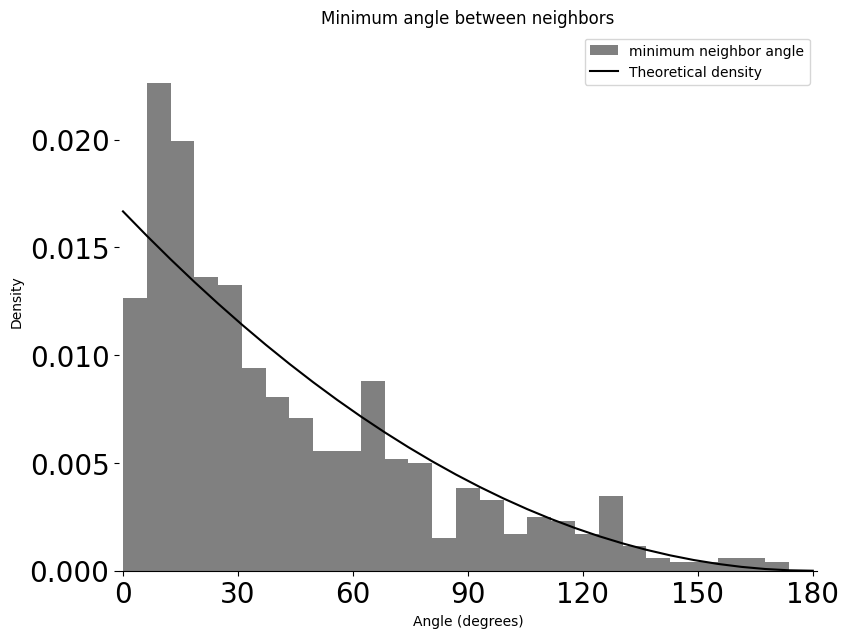

In [8]:
%load_ext autoreload
%autoreload 2

from example_functions import plot_orientations

plot_orientations(all_nn1_distances, all_nn2_distances, all_nn3_distances, all_nn1_angles, all_nn2_angles, all_nn3_angles)



In [9]:

viewer.add_surface((mesh.vertices, mesh.faces[:, [2,1,0]]))
pos = star_data[["rlnCoordinateX", "rlnCoordinateY", "rlnCoordinateZ"]].values
ori = star_data[["rlnAngleRot", "rlnAngleTilt", "rlnAnglePsi"]].values

pos_layer = viewer.add_points(pos)
pos_layer.shading = "spherical"
struc = load_tomogram(structure_file).data * -1
struc[:, :, :35] = -10

verts, faces, normals, values = measure.marching_cubes(struc, 2, step_size=2)
verts -= (np.array(struc.shape) / 2)

rotation_matrices = eulerangles.euler2matrix(
    ori,
    axes="zyz",
    intrinsic=True,
    right_handed_rotation=False
)

/scicore/home/engel0006/GROUP/pool-engel/Lorenz/MemBrain_stats/venv_membrain_stats/lib/python3.11/site-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x44 0x20 0x20 0x20
  warnings.warn(str(err), RuntimeWarning)


In [10]:
import numpy as np
from example_functions import iterative_chain_building, merge_chains, find_pos_index

# Define chain parameters
max_angle = 60 # angle between two orientations of ribosomes
max_angle_connection = 80 # angle between two connections of ribosomes
max_distance = 400 / 7.82 # maximum distance between two ribosomes in pixel space

positions = pos
nearest_neighbors = [
    [find_pos_index(curpos, start_positions) for curpos in [nn1, nn2, nn3]] for nn1, nn2, nn3 in zip(nn1_pos, nn2_pos, nn3_pos)
]
between_angles = [
    [between_angles1[k], between_angles2[k], between_angles3[k]] for k in range(len(between_angles1))
]

# Build chains iteratively
chains = iterative_chain_building(positions, nearest_neighbors, between_angles, max_angle, max_angle_connection, max_distance=max_distance)

merged_chains = chains
merged_chains = merge_chains(
    chains=chains,
    positions=positions,
    nearest_neighbors=nearest_neighbors,
    between_angles=between_angles,
    max_distance=400 / 7.82,
    max_angle_merge_orientation=max_angle,
    max_angle_merge_connection=max_angle_connection
)

In [11]:
all_lines = []
for idx, points in enumerate(merged_chains):
    points_array = positions[points]  # Convert list of points to a numpy array

    if len(points_array) > 1:
        lines = np.array([[points_array[i], points_array[i + 1]] for i in range(len(points_array) - 1)])
        all_lines.append(lines)
all_lines = np.concatenate(all_lines)
viewer.add_shapes(all_lines, shape_type='line', edge_color="black", edge_width=2.5, name="Lines")

<Shapes layer 'Lines' at 0x14dea288e450>

In [12]:
from example_functions import colormaps

surfaces = []
bigger_than2_chains = [chain for chain in merged_chains if len(chain) > 2]
idcs_not_in_chains = set(range(len(positions)))
for chain in bigger_than2_chains:
    for idx in chain:
        idcs_not_in_chains.remove(idx)

for nr, idx_chain in enumerate(bigger_than2_chains):
    chain_verts = []
    chain_faces = []
    for idx in idx_chain:
        cur_verts = verts.copy()
        rotmat = rotation_matrices[idx]
        subpos = pos[idx]
        cur_verts = np.dot(rotmat.T, cur_verts.T).T
        cur_verts += subpos
        chain_verts.append(cur_verts)
        chain_faces.append(faces.copy() + (len(chain_verts) - 1) * len(verts))
        # surfaces.append(viewer.add_surface((cur_verts,faces), colormap=colormaps[nr % len(colormaps)]))
    chain_verts = np.concatenate(chain_verts, axis=0)
    chain_faces = np.concatenate(chain_faces, axis=0)
    surfaces.append(viewer.add_surface((chain_verts,chain_faces), colormap=colormaps[nr % len(colormaps)]))

empty_chain_verts = []
empty_chain_faces = []
for idx in idcs_not_in_chains:
    cur_verts = verts.copy()
    rotmat = rotation_matrices[idx]
    subpos = pos[idx]
    cur_verts = np.dot(rotmat.T, cur_verts.T).T
    cur_verts += subpos
    empty_chain_verts.append(cur_verts)
    empty_chain_faces.append(faces.copy() + (len(empty_chain_verts) - 1) * len(verts))
    # surfaces.append(viewer.add_surface((cur_verts,faces), colormap="gray"))
empty_chain_verts = np.concatenate(empty_chain_verts, axis=0)
empty_chain_faces = np.concatenate(empty_chain_faces, axis=0)
surfaces.append(viewer.add_surface((empty_chain_verts,empty_chain_faces), colormap="gray"))